In [1]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv')
train_series = pd.read_csv('/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series.csv')

print("TRAIN SHAPE:", train.shape)
print("\nTRAIN COLUMNS:")
print(train.columns.tolist())

display(train.head())

print("\n" + "="*80)

print("TRAIN_SERIES SHAPE:", train_series.shape)
print("\nTRAIN_SERIES COLUMNS:")
print(train_series.columns.tolist())

display(train_series.head())

TRAIN SHAPE: (4407, 14)

TRAIN COLUMNS:
['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TRAIN_SERIES SHAPE: (24371, 5)

TRAIN_SERIES COLUMNS:
['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [2]:
import os

root = "/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series"

studies = os.listdir(root)

print("Number of study folders:", len(studies))

sample_study = studies[0]

print("\nSample study:")
print(sample_study)

sample_path = os.path.join(root, sample_study)

print("\nFiles inside sample study:")
print(os.listdir(sample_path)[:20])

Number of study folders: 4407

Sample study:
1.2.826.0.1.3680043.8.498.10843463954622076609489312662891432839

Files inside sample study:
['1.2.826.0.1.3680043.8.498.28798546215369442215420222435134673142', '1.2.826.0.1.3680043.8.498.77574746339062590058612008891367008722', '1.2.826.0.1.3680043.8.498.11095855317733507937819924915747155492', '1.2.826.0.1.3680043.8.498.20777921698448069425369525866577598114', '1.2.826.0.1.3680043.8.498.12352363451108476518578557153043561806']


In [3]:
import os

sample_path = os.path.join(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series",
    os.listdir("/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series")[0]
)

count = 0

for _, _, files in os.walk(sample_path):
    count += sum(f.endswith(".dcm") for f in files)

print("DICOMs in sample study:", count)

DICOMs in sample study: 587


In [4]:
#train.head()
# train_series.head()
# train.columns
train_series.columns

Index(['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive',
       'Fat_Suppression', 'Anatomical_Plane'],
      dtype='object')

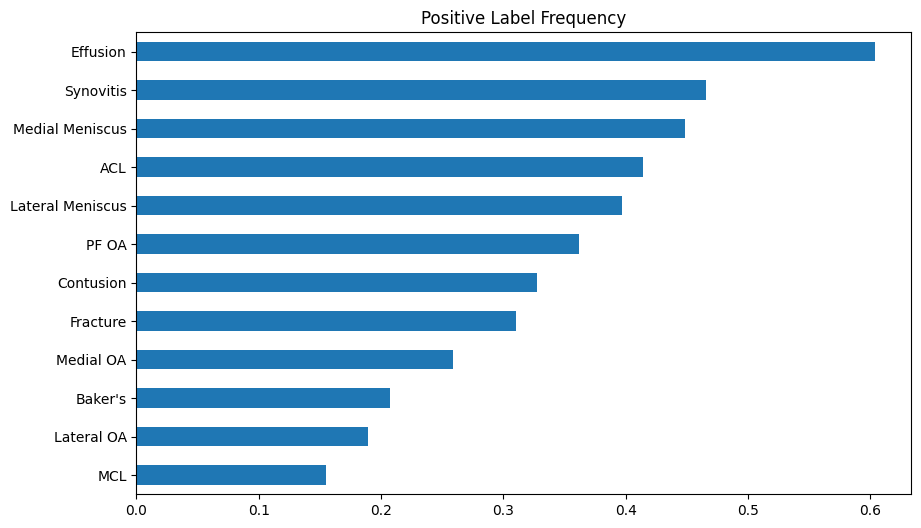

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv"
)

targets = [
    'ACL',
    'MCL',
    'Medial Meniscus',
    'Lateral Meniscus',
    'Medial OA',
    'Lateral OA',
    'PF OA',
    'Effusion',
    'Synovitis',
    "Baker's",
    'Contusion',
    'Fracture'
]

label_freq = train[targets].mean().sort_values()

plt.figure(figsize=(10,6))
label_freq.plot(kind="barh")
plt.title("Positive Label Frequency")
plt.show()

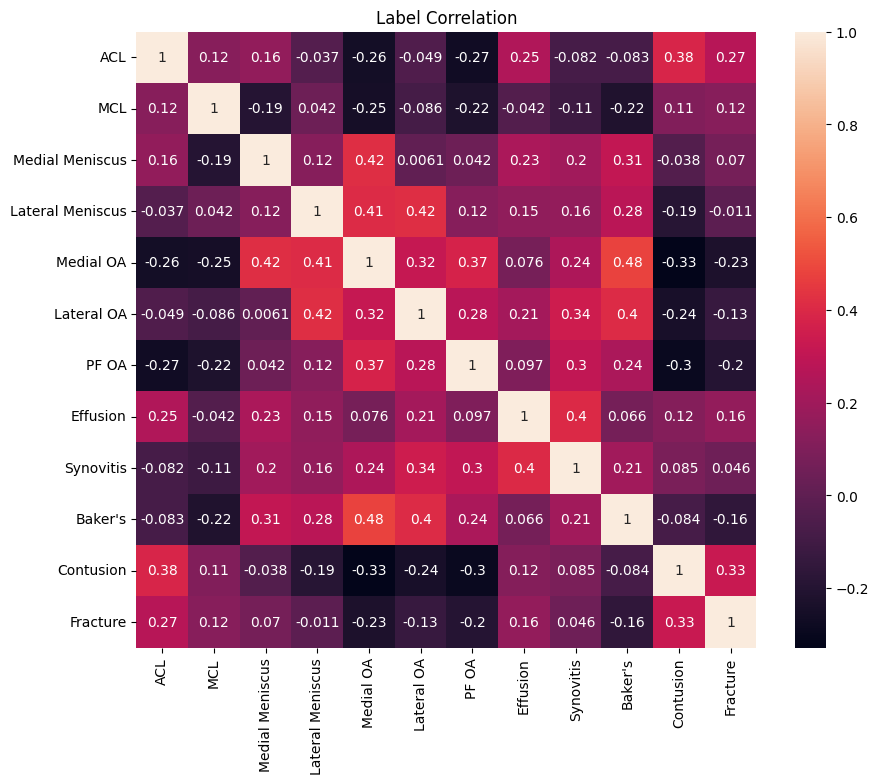

In [6]:
import seaborn as sns

corr = train[targets].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Label Correlation")
plt.show()

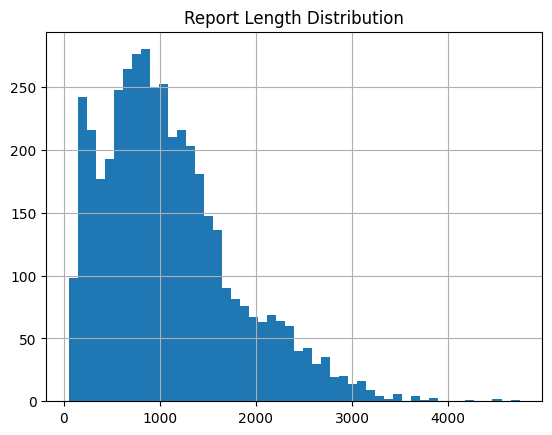

In [7]:
train["report_length"] = train["Report"].str.len()

train["report_length"].hist(bins=50)
plt.title("Report Length Distribution")
plt.show()

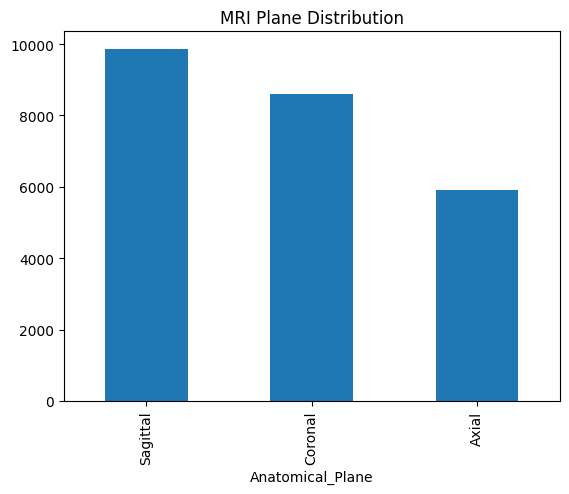

In [8]:
series = pd.read_csv(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series.csv"
)

series["Anatomical_Plane"].value_counts().plot(
    kind="bar"
)
plt.title("MRI Plane Distribution")
plt.show()


In [9]:
train["Report"].iloc[0]

'Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame.'

In [10]:
import pandas as pd

train = pd.read_csv(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv"
)

for i in range(10):
    print("="*100)
    print(train["Report"].iloc[i][:500])

Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame.
[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair gewogen seq zonder en met fs, ax/ cor pd gewogen seq fs, cor T1 gewogen seq Bevindingen:
Hallazgos:
No hay alteraciones en significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Aumento de señal del cuerno posterior del menisco medial que no impresiona contactar con la
superficie articular, sin caracteres propios de rotura.
Menisco lateral de morfología y señal conservada, sin signos de rotura.
Úlceras condrales de espesor parcial con fenómenos condrales reparativos de la re

In [11]:
import pandas as pd

series = pd.read_csv(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series.csv"
)

series_per_study = (
    series.groupby("StudyInstanceUID")
    .size()
)

print(series_per_study.describe())

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


In [12]:
pd.crosstab(
    series["StudyInstanceUID"],
    series["Anatomical_Plane"]
).sum()

Anatomical_Plane
Axial       5898
Coronal     8609
Sagittal    9864
dtype: int64

In [13]:
import pandas as pd

train = pd.read_csv(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv"
)

train["report_length"] = train["Report"].str.len()

targets = [
    'ACL',
    'MCL',
    'Medial Meniscus',
    'Lateral Meniscus',
    'Medial OA',
    'Lateral OA',
    'PF OA',
    'Effusion',
    'Synovitis',
    "Baker's",
    'Contusion',
    'Fracture'
]

for col in targets:
    print(
        col,
        "positive:",
        train.loc[train[col]==1, "report_length"].mean(),
        "negative:",
        train.loc[train[col]==0, "report_length"].mean()
    )

ACL positive: 1252.25 negative: 1342.3823529411766
MCL positive: 1514.5555555555557 negative: 1266.6122448979593
Medial Meniscus positive: 1476.8461538461538 negative: 1165.53125
Lateral Meniscus positive: 1640.9565217391305 negative: 1084.3714285714286
Medial OA positive: 1631.2666666666667 negative: 1191.3023255813953
Lateral OA positive: 1613.3636363636363 negative: 1232.936170212766
PF OA positive: 1323.3809523809523 negative: 1294.7027027027027
Effusion positive: 1391.6571428571428 negative: 1173.3478260869565
Synovitis positive: 1254.9259259259259 negative: 1348.774193548387
Baker's positive: 1475.5833333333333 negative: 1260.608695652174
Contusion positive: 1428.421052631579 negative: 1245.0
Fracture positive: 1327.1666666666667 negative: 1295.15


In [14]:
!pip install -q scikit-learn

In [15]:
import pandas as pd
import numpy as np

TRAIN_PATH = "/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv"

train = pd.read_csv(TRAIN_PATH)

print(train.shape)
train.head()

(4407, 14)


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
targets = [
    'ACL',
    'MCL',
    'Medial Meniscus',
    'Lateral Meniscus',
    'Medial OA',
    'Lateral OA',
    'PF OA',
    'Effusion',
    'Synovitis',
    "Baker's",
    'Contusion',
    'Fracture'
]

In [17]:
from sklearn.model_selection import train_test_split

X_train_text, X_valid_text, y_train, y_valid = train_test_split(
    train["Report"],
    train[targets],
    test_size=0.2,
    random_state=42
)

print(X_train_text.shape)
print(X_valid_text.shape)

(3525,)
(882,)


In [18]:
!pip install -q transformers datasets accelerate sentencepiece

In [20]:
print(type(X_train_text))
print(type(X_valid_text))
print(type(y_train))
print(type(y_valid))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [21]:
print(X_train_text.shape)
print(X_valid_text.shape)
print(y_train.shape)
print(y_valid.shape)

(3525,)
(882,)
(3525, 12)
(882, 12)


In [22]:
import pandas as pd

train_df = pd.concat(
    [X_train_text.reset_index(drop=True),
     y_train.reset_index(drop=True)],
    axis=1
)

valid_df = pd.concat(
    [X_valid_text.reset_index(drop=True),
     y_valid.reset_index(drop=True)],
    axis=1
)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

display(train_df.head())

Train: (3525, 13)
Valid: (882, 13)


,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MRI KNEE - RIGHT\n\nTECHNIQUE: Unenhanced ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Exam Type: MRI KNEE LEFT WO CONTRAST\nExam Dat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bone bruise at posteromedial and posterolater...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Findings: There is a mild knee effusion. Ther...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
from datasets import Dataset
from transformers import AutoTokenizer

print("Imports successful")

Imports successful


In [24]:
train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

print(train_ds)
print(valid_ds)

Dataset({
    features: ['Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture'],
    num_rows: 3525
})
Dataset({
    features: ['Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture'],
    num_rows: 882
})


In [25]:
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [26]:
lengths = train_df["Report"].apply(
    lambda x: len(tokenizer(str(x))["input_ids"])
)

print(lengths.describe())

Token indices sequence length is longer than the specified maximum sequence length for this model (1000 > 512). Running this sequence through the model will result in indexing errors


count    3525.000000
mean      315.965106
std       195.596389
min        19.000000
25%       170.000000
50%       286.000000
75%       418.000000
max      1242.000000
Name: Report, dtype: float64


In [27]:
print("Reports > 512 tokens:",
      (lengths > 512).sum())

print("Percentage:",
      round(100*(lengths > 512).mean(),2),
      "%")

Reports > 512 tokens: 529
Percentage: 15.01 %


In [28]:
def tokenize(batch):
    return tokenizer(
        batch["Report"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

train_ds = train_ds.map(
    tokenize,
    batched=True
)

valid_ds = valid_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/3525 [00:00<?, ? examples/s]

Map:   0%|          | 0/882 [00:00<?, ? examples/s]

In [29]:
print(train_ds.column_names)

['Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture', 'input_ids', 'attention_mask']


In [31]:
targets = [
    'ACL',
    'MCL',
    'Medial Meniscus',
    'Lateral Meniscus',
    'Medial OA',
    'Lateral OA',
    'PF OA',
    'Effusion',
    'Synovitis',
    "Baker's",
    'Contusion',
    'Fracture'
]

def add_labels(example):
    
    example["labels"] = [
        float(example[t])
        for t in targets
    ]
    
    return example

In [34]:
print(train_ds[0])

{'Report': 'Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Condropatía troclear. Impresión: Rotura de menisco interno. Condropatía troclear.', 'ACL': None, 'MCL': None, 'Medial Meniscus': None, 'Lateral Meniscus': None, 'Medial OA': None, 'Lateral OA': None, 'PF OA': None, 'Effusion': None, 'Synovitis': None, "Baker's": None, 'Contusion': None, 'Fracture': None, 'input_ids': [0, 151042, 12, 12174, 839, 8, 21, 150674, 143, 5, 187054, 7, 12, 2777, 3595, 8, 13268, 12064, 46188, 5, 1657, 5814, 4453, 3290, 3428, 119488, 5, 3370, 93381, 12, 2777, 3595, 8, 13268, 12064, 46188, 5, 1657, 5814, 4453, 3290, 3428, 119488, 5, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [35]:
for col in targets:
    print(col, train_ds[0][col], type(train_ds[0][col]))

ACL None <class 'NoneType'>
MCL None <class 'NoneType'>
Medial Meniscus None <class 'NoneType'>
Lateral Meniscus None <class 'NoneType'>
Medial OA None <class 'NoneType'>
Lateral OA None <class 'NoneType'>
PF OA None <class 'NoneType'>
Effusion None <class 'NoneType'>
Synovitis None <class 'NoneType'>
Baker's None <class 'NoneType'>
Contusion None <class 'NoneType'>
Fracture None <class 'NoneType'>


In [36]:
for col in targets:
    print(col, train_df[col].isna().sum())

ACL 3477
MCL 3477
Medial Meniscus 3477
Lateral Meniscus 3477
Medial OA 3477
Lateral OA 3477
PF OA 3477
Effusion 3477
Synovitis 3477
Baker's 3477
Contusion 3477
Fracture 3477


In [37]:
print(train_df.head())

print("\nColumns:")
print(train_df.columns)

print("\nNull counts:")
print(train_df.isnull().sum())

                                              Report  ACL  MCL  \
0  Técnica: RMN de la rodilla. Resultados: Rotura...  NaN  NaN   
1  MRI  KNEE  -  RIGHT\n\nTECHNIQUE:  Unenhanced ...  NaN  NaN   
2  Exam Type: MRI KNEE LEFT WO CONTRAST\nExam Dat...  NaN  NaN   
3   Bone bruise at posteromedial and posterolater...  NaN  NaN   
4  Findings:  There is a mild knee effusion. Ther...  NaN  NaN   

   Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  \
0              NaN               NaN        NaN         NaN    NaN       NaN   
1              NaN               NaN        NaN         NaN    NaN       NaN   
2              NaN               NaN        NaN         NaN    NaN       NaN   
3              NaN               NaN        NaN         NaN    NaN       NaN   
4              NaN               NaN        NaN         NaN    NaN       NaN   

   Synovitis  Baker's  Contusion  Fracture  
0        NaN      NaN        NaN       NaN  
1        NaN      NaN        NaN

In [38]:
print(y_train.head())

      ACL  MCL  Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  \
4336  NaN  NaN              NaN               NaN        NaN         NaN   
3505  NaN  NaN              NaN               NaN        NaN         NaN   
3134  NaN  NaN              NaN               NaN        NaN         NaN   
1448  NaN  NaN              NaN               NaN        NaN         NaN   
1749  NaN  NaN              NaN               NaN        NaN         NaN   

      PF OA  Effusion  Synovitis  Baker's  Contusion  Fracture  
4336    NaN       NaN        NaN      NaN        NaN       NaN  
3505    NaN       NaN        NaN      NaN        NaN       NaN  
3134    NaN       NaN        NaN      NaN        NaN       NaN  
1448    NaN       NaN        NaN      NaN        NaN       NaN  
1749    NaN       NaN        NaN      NaN        NaN       NaN  


In [39]:
print(train.shape)

print(train[[
    'ACL',
    'MCL',
    'Medial Meniscus',
    'Lateral Meniscus',
    'Medial OA',
    'Lateral OA',
    'PF OA',
    'Effusion',
    'Synovitis',
    "Baker's",
    'Contusion',
    'Fracture'
]].isnull().sum())

(4407, 14)
ACL                 4349
MCL                 4349
Medial Meniscus     4349
Lateral Meniscus    4349
Medial OA           4349
Lateral OA          4349
PF OA               4349
Effusion            4349
Synovitis           4349
Baker's             4349
Contusion           4349
Fracture            4349
dtype: int64


In [40]:
train.head()

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
train[['ACL','MCL','Medial Meniscus','Lateral Meniscus',
       'Medial OA','Lateral OA','PF OA','Effusion',
       'Synovitis',"Baker's",'Contusion','Fracture']].notna().sum()

ACL                 58
MCL                 58
Medial Meniscus     58
Lateral Meniscus    58
Medial OA           58
Lateral OA          58
PF OA               58
Effusion            58
Synovitis           58
Baker's             58
Contusion           58
Fracture            58
dtype: int64

In [43]:
labeled = train[train['ACL'].notna()]

print("Labeled studies:", len(labeled))

display(labeled.head())

Labeled studies: 58


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
63,1.2.826.0.1.3680043.8.498.10170898615867673028...,The study reveals normal knee joint alignment...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
109,1.2.826.0.1.3680043.8.498.10306159113324811538...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
445,1.2.826.0.1.3680043.8.498.11287937729196958426...,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
470,1.2.826.0.1.3680043.8.498.11382021393803389951...,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
print("Total studies:", len(train))

labeled = train[train['ACL'].notna()]

print("Labeled studies:", len(labeled))

print("Percentage labeled:",
      round(100 * len(labeled) / len(train), 2), "%")

Total studies: 4407
Labeled studies: 58
Percentage labeled: 1.32 %


In [45]:
targets = [
    'ACL','MCL','Medial Meniscus','Lateral Meniscus',
    'Medial OA','Lateral OA','PF OA','Effusion',
    'Synovitis',"Baker's",'Contusion','Fracture'
]

labeled = train[train['ACL'].notna()]

for col in targets:
    print(col, labeled[col].value_counts())
    print()

ACL ACL
0.0    34
1.0    24
Name: count, dtype: int64

MCL MCL
0.0    49
1.0     9
Name: count, dtype: int64

Medial Meniscus Medial Meniscus
0.0    32
1.0    26
Name: count, dtype: int64

Lateral Meniscus Lateral Meniscus
0.0    35
1.0    23
Name: count, dtype: int64

Medial OA Medial OA
0.0    43
1.0    15
Name: count, dtype: int64

Lateral OA Lateral OA
0.0    47
1.0    11
Name: count, dtype: int64

PF OA PF OA
0.0    37
1.0    21
Name: count, dtype: int64

Effusion Effusion
1.0    35
0.0    23
Name: count, dtype: int64

Synovitis Synovitis
0.0    31
1.0    27
Name: count, dtype: int64

Baker's Baker's
0.0    46
1.0    12
Name: count, dtype: int64

Contusion Contusion
0.0    39
1.0    19
Name: count, dtype: int64

Fracture Fracture
0.0    40
1.0    18
Name: count, dtype: int64



In [47]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993331 sha256=d47da66c14fd77dcfe530f300cd753690c16a74e0f5911bb3f76ea9a1b9ef99a
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [48]:
from langdetect import detect
from collections import Counter

langs = []

for text in train["Report"].sample(min(500, len(train)), random_state=42):
    try:
        langs.append(detect(text))
    except:
        pass

Counter(langs)

Counter({'de': 29,
         'tr': 69,
         'hr': 53,
         'el': 40,
         'en': 179,
         'es': 78,
         'bg': 28,
         'nl': 16,
         'fr': 8})

In [49]:
targets = [
    'ACL','MCL','Medial Meniscus','Lateral Meniscus',
    'Medial OA','Lateral OA','PF OA','Effusion',
    'Synovitis',"Baker's",'Contusion','Fracture'
]

labeled = train[train['ACL'].notna()].copy()

print("Labeled samples:", len(labeled))

X = labeled["Report"]
y = labeled[targets]

print(X.shape)
print(y.shape)

Labeled samples: 58
(58,)
(58, 12)


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words=None
)

X_tfidf = vectorizer.fit_transform(X)

print(X_tfidf.shape)

(58, 6874)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(46, 6874)
(12, 6874)


In [52]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )
)

model.fit(X_train, y_train)

print("Training complete")

Training complete


In [53]:
from sklearn.metrics import roc_auc_score

preds = model.predict_proba(X_val)

print("Pred shape:", preds.shape)

try:
    auc = roc_auc_score(
        y_val,
        preds,
        average="macro"
    )
    print("Macro ROC-AUC:", auc)
except Exception as e:
    print("Error:", e)

Pred shape: (12, 12)
Macro ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [54]:
for col in y_val.columns:
    print(col)
    print(y_val[col].value_counts())
    print("-"*30)

ACL
ACL
0.0    9
1.0    3
Name: count, dtype: int64
------------------------------
MCL
MCL
0.0    9
1.0    3
Name: count, dtype: int64
------------------------------
Medial Meniscus
Medial Meniscus
0.0    7
1.0    5
Name: count, dtype: int64
------------------------------
Lateral Meniscus
Lateral Meniscus
0.0    8
1.0    4
Name: count, dtype: int64
------------------------------
Medial OA
Medial OA
0.0    8
1.0    4
Name: count, dtype: int64
------------------------------
Lateral OA
Lateral OA
0.0    12
Name: count, dtype: int64
------------------------------
PF OA
PF OA
0.0    8
1.0    4
Name: count, dtype: int64
------------------------------
Effusion
Effusion
1.0    8
0.0    4
Name: count, dtype: int64
------------------------------
Synovitis
Synovitis
0.0    8
1.0    4
Name: count, dtype: int64
------------------------------
Baker's
Baker's
0.0    10
1.0     2
Name: count, dtype: int64
------------------------------
Contusion
Contusion
0.0    10
1.0     2
Name: count, dtype: int64


In [55]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_tfidf)):

    X_tr = X_tfidf[train_idx]
    X_va = X_tfidf[val_idx]

    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]

    model = OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X_tr, y_tr)

    preds = model.predict_proba(X_va)

    aucs = []

    for i, col in enumerate(targets):

        if len(np.unique(y_va[col])) > 1:
            aucs.append(
                roc_auc_score(
                    y_va[col],
                    preds[:, i]
                )
            )

    fold_auc = np.mean(aucs)

    print(f"Fold {fold+1}: {fold_auc:.4f}")

    scores.append(fold_auc)

print()
print("Mean CV AUC:", np.mean(scores))

Fold 1: 0.5476
Fold 2: 0.5843
Fold 3: 0.5909
Fold 4: 0.6609
Fold 5: 0.6165

Mean CV AUC: 0.6000580908289243


In [56]:
targets = [
    'ACL','MCL','Medial Meniscus','Lateral Meniscus',
    'Medial OA','Lateral OA','PF OA','Effusion',
    'Synovitis',"Baker's",'Contusion','Fracture'
]

for t in targets:
    print("\n", t)
    print(train[train[t] == 1]["Report"].head(3).tolist())


 ACL
[' In the medial compartment, there is longitudinal vertical tear at the body and posterior horn of the medial meniscus. There is no focal chondrosis or chondral injury. \n The lateral compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. \n The patellofemoral joint, the patellar and trochlear cartilage appears congruent without chondral lesion. The medial patellofemoral ligament is intact.  \n In the intercondylar notch, there is complete tear of the anterior cruciate ligament, at mid substance. The posterior cruciate ligament is intact. There is anterior tibial translation.   \n The medial and lateral collateral ligament complexes are intact. The extensor mechanism is normal.  \n No knee effusion is present. The surrounding musculature is normal. There is no fracture or bone contusion.   -- Longitudinal vertical tear at the body and posterior horn of the medial meniscus. \n -- Complete tear of the anterior cruciate ligament, at mid substance

In [57]:
targets = [
    'ACL','MCL','Medial Meniscus','Lateral Meniscus',
    'Medial OA','Lateral OA','PF OA','Effusion',
    'Synovitis',"Baker's",'Contusion','Fracture'
]

for t in targets:
    print("="*80)
    print(t)
    print("="*80)

    positives = labeled[labeled[t] == 1]

    for r in positives["Report"].head(3):
        print(r[:1500])
        print("-"*50)

ACL
 In the medial compartment, there is longitudinal vertical tear at the body and posterior horn of the medial meniscus. There is no focal chondrosis or chondral injury. 
 The lateral compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. 
 The patellofemoral joint, the patellar and trochlear cartilage appears congruent without chondral lesion. The medial patellofemoral ligament is intact.  
 In the intercondylar notch, there is complete tear of the anterior cruciate ligament, at mid substance. The posterior cruciate ligament is intact. There is anterior tibial translation.   
 The medial and lateral collateral ligament complexes are intact. The extensor mechanism is normal.  
 No knee effusion is present. The surrounding musculature is normal. There is no fracture or bone contusion.   -- Longitudinal vertical tear at the body and posterior horn of the medial meniscus. 
 -- Complete tear of the anterior cruciate ligament, at mid substance. 
-------

In [58]:
import re
import pandas as pd

reports = train.copy()

reports["text"] = reports["Report"].fillna("").str.lower()

In [66]:
import re

RULES = {

    "ACL": {
        "pos": [
            r"acl tear",
            r"complete acl tear",
            r"partial acl tear",
            r"acl rupture",
            r"chronic torn acl",
            r"anterior cruciate ligament tear",
            r"anterior cruciate ligament rupture",
            r"desgarro.*lca",
            r"rotura.*lca",
        ],
        "neg": [
            r"normal acl",
            r"acl intact",
            r"acl preserved",
            r"no acl tear",
            r"no evidence of acl tear",
            r"anterior cruciate ligament is intact",
            r"continuity.*acl.*preserved",
            r"without evidence of ligament tear",
        ]
    },

    "MCL": {
        "pos": [
            r"mcl tear",
            r"mcl sprain",
            r"mcl strain",
            r"medial collateral ligament tear",
            r"medial collateral ligament sprain",
            r"grade i mcl",
            r"grade ii mcl",
        ],
        "neg": [
            r"normal mcl",
            r"mcl intact",
            r"mcl preserved",
            r"medial collateral ligament intact",
            r"medial collateral ligament normal",
        ]
    },

    "Medial Meniscus": {
        "pos": [
            r"medial meniscus tear",
            r"medial meniscal tear",
            r"tear of.*medial meniscus",
            r"posterior horn.*medial meniscus.*tear",
            r"rotura de menisco interno",
            r"desgarro.*menisco medial",
        ],
        "neg": [
            r"medial meniscus normal",
            r"no tear.*medial meniscus",
            r"medial meniscus is not torn",
        ]
    },

    "Lateral Meniscus": {
        "pos": [
            r"lateral meniscus tear",
            r"lateral meniscal tear",
            r"tear of.*lateral meniscus",
            r"complex tear.*lateral meniscus",
        ],
        "neg": [
            r"lateral meniscus normal",
            r"no tear.*lateral meniscus",
            r"lateral meniscus is not torn",
        ]
    },

    "Medial OA": {
        "pos": [
            r"medial osteoarthritis",
            r"medial oa",
            r"medial compartment osteoarthritis",
            r"artrosis femorotibial medial",
            r"medial compartment chondrosis",
            r"medial compartment cartilage loss",
        ],
        "neg": []
    },

    "Lateral OA": {
        "pos": [
            r"lateral osteoarthritis",
            r"lateral oa",
            r"lateral compartment osteoarthritis",
            r"lateral compartment chondrosis",
            r"lateral compartment cartilage loss",
        ],
        "neg": []
    },

    "PF OA": {
        "pos": [
            r"patellofemoral osteoarthritis",
            r"pf oa",
            r"patellofemoral chondrosis",
            r"patellar chondrosis",
            r"chondromalacia patella",
            r"condromalacia rotuliana",
            r"retropatellar chondropathy",
        ],
        "neg": []
    },

    "Effusion": {
        "pos": [
            r"joint effusion",
            r"knee effusion",
            r"small effusion",
            r"moderate effusion",
            r"large effusion",
            r"effusion",
            r"derrame",
            r"ставен излив",
        ],
        "neg": [
            r"no effusion",
            r"without effusion",
            r"no joint effusion",
        ]
    },

    "Synovitis": {
        "pos": [
            r"synovitis",
            r"synovial hypertrophy",
            r"synovial thickening",
        ],
        "neg": [
            r"no synovitis",
        ]
    },

    "Baker's": {
        "pos": [
            r"baker'?s cyst",
            r"popliteal cyst",
            r"quiste popl[ií]teo",
        ],
        "neg": [
            r"no baker'?s cyst",
            r"no popliteal cyst",
        ]
    },

    "Contusion": {
        "pos": [
            r"bone contusion",
            r"bone bruise",
            r"contusion",
            r"osseous contusion",
        ],
        "neg": []
    },

    "Fracture": {
        "pos": [
            r"fracture",
            r"avulsion fracture",
            r"tibial eminence fracture",
        ],
        "neg": [
            r"no fracture",
            r"without fracture",
            r"fractures:\s*aucune",
        ]
    },
}

In [67]:
def apply_rules(text):
    text = str(text).lower()

    preds = {}

    for label, rule in RULES.items():

        pos = any(re.search(p, text) for p in rule["pos"])
        neg = any(re.search(p, text) for p in rule["neg"])

        preds[label] = int(pos and not neg)

    return preds

In [68]:
pseudo = train.copy()

for label in RULES.keys():
    pseudo[f"{label}_pseudo"] = pseudo["Report"].apply(
        lambda x: apply_rules(x)[label]
    )

In [69]:
for label in RULES.keys():
    print(label,
          pseudo[f"{label}_pseudo"].sum())

ACL 136
MCL 59
Medial Meniscus 556
Lateral Meniscus 291
Medial OA 42
Lateral OA 16
PF OA 115
Effusion 1906
Synovitis 300
Baker's 489
Contusion 736
Fracture 491


In [70]:
TARGETS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

pseudo_df = pseudo.copy()

for t in TARGETS:
    pseudo_df[t] = pseudo_df[f"{t}_pseudo"]

pseudo_df = pseudo_df[["Report"] + TARGETS]

print(pseudo_df.shape)
pseudo_df.head()

(4407, 13)


,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,Técnica: RMN de la rodilla. Resultados: Rotura...,0,0,1,0,1,0,0,1,0,0,0,0
1,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,0,0,0,0,0,0,0,0,0,0,0,0
2,Hallazgos:\nNo hay alteraciones en significati...,0,0,0,0,0,0,0,1,0,0,0,0
3,"In the medial compartment, the meniscus is no...",0,0,0,0,0,0,0,1,0,0,1,0
4,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,0,0,0,0,0,0,0,0,0,0,0,1


In [71]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    pseudo_df,
    test_size=0.1,
    random_state=42
)

print(train_df.shape)
print(valid_df.shape)

(3966, 13)
(441, 13)


In [72]:
from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded")

Tokenizer loaded


In [73]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
valid_ds = Dataset.from_pandas(valid_df.reset_index(drop=True))

print(train_ds)
print(valid_ds)

Dataset({
    features: ['Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture'],
    num_rows: 3966
})
Dataset({
    features: ['Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture'],
    num_rows: 441
})


In [74]:
TARGETS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

def add_labels(example):
    example["labels"] = [float(example[t]) for t in TARGETS]
    return example

train_ds = train_ds.map(add_labels)
valid_ds = valid_ds.map(add_labels)

print(train_ds[0]["labels"])

Map:   0%|          | 0/3966 [00:00<?, ? examples/s]

Map:   0%|          | 0/441 [00:00<?, ? examples/s]

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [75]:
MAX_LEN = 512

def tokenize(batch):
    return tokenizer(
        batch["Report"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(
    tokenize,
    batched=True,
    batch_size=128
)

valid_ds = valid_ds.map(
    tokenize,
    batched=True,
    batch_size=128
)

print(train_ds[0].keys())

Map:   0%|          | 0/3966 [00:00<?, ? examples/s]

Map:   0%|          | 0/441 [00:00<?, ? examples/s]

dict_keys(['Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture', 'labels', 'input_ids', 'attention_mask'])


In [76]:
train_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

valid_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(train_ds[0]["input_ids"].shape)
print(train_ds[0]["labels"].shape)

torch.Size([512])
torch.Size([12])


In [77]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=12,
    problem_type="multi_label_classification"
)

print("Model loaded")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [78]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

True
2
0 Tesla T4
1 Tesla T4


In [79]:
import numpy as np
from sklearn.metrics import roc_auc_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))

    aucs = []

    for i in range(labels.shape[1]):

        if len(np.unique(labels[:, i])) < 2:
            continue

        auc = roc_auc_score(
            labels[:, i],
            probs[:, i]
        )

        aucs.append(auc)

    return {
        "macro_auc": np.mean(aucs)
    }

In [80]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./knee_xlmr",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="macro_auc",
    greater_is_better=True,

    fp16=True,

    logging_steps=50,

    report_to="none"
)

In [81]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_ds,
    eval_dataset=valid_ds,

    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [82]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Macro Auc
1,0.365659,0.300995,0.872766
2,0.264059,0.237097,0.898670
3,0.226326,0.207663,0.915816


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1488, training_loss=0.33096142097186015, metrics={'train_runtime': 1055.4085, 'train_samples_per_second': 11.273, 'train_steps_per_second': 1.41, 'total_flos': 3130776411217920.0, 'train_loss': 0.33096142097186015, 'epoch': 3.0})

In [83]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.20766310393810272,
 'eval_macro_auc': 0.9158164449669794,
 'eval_runtime': 9.4126,
 'eval_samples_per_second': 46.852,
 'eval_steps_per_second': 2.975,
 'epoch': 3.0}

In [84]:
trainer.save_model("/kaggle/working/xlmr_knee_model")
tokenizer.save_pretrained("/kaggle/working/xlmr_knee_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/xlmr_knee_model/tokenizer_config.json',
 '/kaggle/working/xlmr_knee_model/tokenizer.json')

In [86]:
!ls -lh /kaggle/working/xlmr_knee_model

total 1.1G
-rw-r--r-- 1 root root 1.3K Aug 31 02:48 config.json
-rw-r--r-- 1 root root 1.1G Aug 31 02:48 model.safetensors
-rw-r--r-- 1 root root  314 Aug 31 02:48 tokenizer_config.json
-rw-r--r-- 1 root root  17M Aug 31 02:48 tokenizer.json
-rw-r--r-- 1 root root 5.1K Aug 31 02:48 training_args.bin


In [87]:
!zip -r xlmr_knee_model.zip /kaggle/working/xlmr_knee_model

  adding: kaggle/working/xlmr_knee_model/ (stored 0%)
  adding: kaggle/working/xlmr_knee_model/tokenizer.json (deflated 77%)
  adding: kaggle/working/xlmr_knee_model/training_args.bin (deflated 53%)
  adding: kaggle/working/xlmr_knee_model/config.json (deflated 59%)
  adding: kaggle/working/xlmr_knee_model/model.safetensors (deflated 25%)
  adding: kaggle/working/xlmr_knee_model/tokenizer_config.json (deflated 47%)
